# Regression example with `c4fairness`

`c4fairness` clusters the test set on the features, letting the data's own geometry define the subgroups, and then reports the model's error per cluster alongside which protected groups each cluster concentrates. Pockets of high or biased error that a per-attribute average washes out show up as their own clusters, each with a significance test attached.

For regression the error is the signed residual `y_true - y_pred`, which carries two things at once: its sign (the direction of bias) and its magnitude (reliability, how large the misses are regardless of direction).

This notebook runs the full audit with the Python API, then shows the two variants that matter in practice: Gower distance for mixed numeric/categorical data and k-selection, which the CLI `--experiment` mode sweeps automatically.

Data: `datasets/student_grades.csv` (670 students, each row carrying the model's `y_pred`). Sensitive attributes cover all three kinds: binary `sex_F`, multi-categorical `Medu` (mother's education, 0-4), and numeric `age`.

In [1]:
import numpy as np
import pandas as pd
from c4fairness.result_viz import plot_cluster_recap_heatmap
from IPython.display import Image

df = pd.read_csv("datasets/student_grades.csv")
df[["G1", "G2", "studytime", "absences", "sex_F", "Medu", "age", "y_true", "y_pred"]].head()

,G1,G2,studytime,absences,sex_F,Medu,age,y_true,y_pred
0,5,6,2,6,1,4,18,6,5.6448
1,5,5,2,4,1,1,17,6,4.2909
2,7,8,2,10,1,1,15,10,6.9731
3,15,14,3,2,1,4,15,15,14.0416
4,6,10,2,4,1,3,16,10,9.2546


## 1. The residual

`residual = y_true - y_pred`. Positive means the true grade was higher than predicted, so the model under-predicted. Negative means it over-predicted.

The mean residual measures bias, a systematic lean in one direction. The mean absolute residual measures typical error size, ignoring direction. A mean residual near zero overall proves nothing about fairness: a cluster the model over-predicts by +2 and another it under-predicts by -2 cancel in the global average while both are badly biased.

In [2]:
residual = df["y_true"] - df["y_pred"]
print(f"overall mean residual   = {residual.mean():+.3f}   (bias direction)")
print(f"overall mean |residual| = {residual.abs().mean():.3f}   (typical error size)")

overall mean residual   = +0.007   (bias direction)
overall mean |residual| = 1.059   (typical error size)


## 2. The aggregate view

The conventional check is one number per protected group, the mean residual within each level of `sex_F` and of `Medu`.

It sees only the axis you chose, and it averages within the group. Grouping by `Medu` can only reveal disparity that lines up with maternal education, and a `Medu` level whose mean residual is near zero may still contain a sharply biased sub-population. Read the numbers below as the baseline.

In [3]:
tmp = df.assign(residual=residual)
print("mean residual by sex_F (0=male, 1=female):")
print(tmp.groupby("sex_F")["residual"].mean().round(3), "\n")
print("mean residual by Medu (mother's education 0-4):")
print(tmp.groupby("Medu")["residual"].mean().round(3))

mean residual by sex_F (0=male, 1=female):
sex_F
0   -0.058
1    0.053
Name: residual, dtype: float64 

mean residual by Medu (mother's education 0-4):
Medu
0    0.581
1    0.067
2   -0.097
3    0.105
4   -0.033
Name: residual, dtype: float64


## 3. Encode and cluster

Clustering needs a numeric feature matrix and a distance. The baseline is one-hot encoding plus Euclidean distance, which `encode_categoricals(..., distance="euclidean")` prepares.

`Medu` is marked categorical. It is an integer code 0-4, not a quantity, and left as a number Euclidean distance would treat `Medu=4` as twice as far from `0` as `Medu=2` is. One-hot encoding avoids imposing spacing the codes do not carry. `age` stays continuous, where the numeric spacing is meaningful.

`encode_categoricals` also returns `multiclass_dummies` (mcd), the map from `Medu` to the dummy columns it expanded into, which we use later to rebuild a single readable `Medu` column. It keeps the 0/1 dummies out of `StandardScaler`, since standardising a binary indicator rescales it by its own frequency and distorts distances. Section 7 covers that failure mode.

In [4]:
from c4fairness.preprocessing import encode_categoricals
from c4fairness.clustering import cluster

sensitive = ["sex_F", "Medu", "age"]
col_lists = {"regular": ["G1", "G2", "studytime", "absences"], "sensitive": sensitive,
             "proxy": [], "special": []}
orig_sensitive = list(sensitive)

dfe, cl, cat_names, mcd, ohe = encode_categoricals(
    df.copy(), col_lists, ["Medu"], "kmeans", distance="euclidean"
)
clustering_cols = cl["regular"] + cl["sensitive"]
res = cluster(dfe[clustering_cols], algorithm="kmeans", distance="euclidean",
              n_clusters=3, random_state=42)
print(f"k = {res.n_clusters}   silhouette = {res.silhouette:.3f}   sizes = {res.cluster_sizes}")

k = 3   silhouette = 0.215   sizes = {np.int32(0): np.int64(152), np.int32(1): np.int64(176), np.int32(2): np.int64(342)}


## 4. The per-cluster recap

`make_recap` collapses the clustered data into one row per cluster. `error_type="regression"` treats the error column as continuous rather than a 0/1 outcome, which changes two things: it reports the signed median residual (`error_mean`, the bias) and its magnitude (`abs_error_mean`, the reliability) instead of a rate, and it tests significance with Mann-Whitney / ANOVA rather than Fisher's exact test, which is for 2x2 count tables.

Sensitive features are shown in salient form, one readable column per attribute with its dominant category, except `age`, declared continuous and summarised by its median. `build_sensitive_analysis_list` names the columns to analyse and `apply_salient_reconstruction` rebuilds `Medu` from its dummies.

In [5]:
from c4fairness.cli import build_sensitive_analysis_list, apply_salient_reconstruction
from c4fairness.experiments import make_recap

analysis = build_sensitive_analysis_list(cl["sensitive"], mcd, orig_sensitive, option="salient")
dfe["residual"] = residual.values
res_df = dfe.copy()
res_df["clusters"] = res.labels
apply_salient_reconstruction(res_df, mcd, orig_sensitive)

recap = make_recap(res_df, clustering_cols, sensitive_cols=analysis,
                   error_col="residual", error_type="regression",
                   feature_matrix=res.feature_matrix, continuous_sensitive_cols=["age"])
recap.round(3)

,c,count,proportion,error_mean,abs_error_mean,error_gap,error_gap_sig,sex_F_value,sex_F_gap,sex_F_gap_sig,age_value,age_gap,age_gap_sig,Medu_value,Medu_cat,Medu_gap,Medu_gap_cat,Medu_gap_sig,silh
0,0,152,0.227,0.067,1.033,0.078,0.544,0.625,0.050,0.317,17.0,0.0,0.025,1.000,1,1.000,1,0.0,0.369
1,1,176,0.263,-0.033,0.992,-0.055,0.566,0.511,-0.102,0.023,16.5,-0.5,0.004,1.000,4,1.000,4,0.0,0.305
2,2,342,0.510,0.001,1.105,-0.012,0.998,0.608,0.044,0.279,17.0,0.0,0.537,0.558,2,0.558,2,0.0,0.100


## 5. Reading the recap

One row per cluster:

- `error_mean`: the cluster's median signed residual. Positive means the model under-predicts these students' grades, negative means it over-predicts.
- `abs_error_mean`: typical error size in the cluster. High here with `error_mean` near zero means the model is unreliable rather than biased.
- `error_gap`: this cluster's error minus the error of everyone else, one-vs-all.
- `error_gap_sig`: p-value for that gap (Mann-Whitney). A big gap with a large p-value in a tiny cluster is not worth reading much into.
- `Medu_cat`, `sex_F_value`, `age_value`: the composition. Which maternal-education level dominates, the share of female students, the median age.

The cluster to worry about has a large absolute bias and a significant gap. Sort by absolute bias:

In [6]:
view = recap.assign(abs_bias=recap["error_mean"].abs()).sort_values("abs_bias", ascending=False)
view[["c", "count", "error_mean", "abs_error_mean", "error_gap", "error_gap_sig",
      "Medu_cat", "sex_F_value", "age_value"]].round(3)

,c,count,error_mean,abs_error_mean,error_gap,error_gap_sig,Medu_cat,sex_F_value,age_value
0,0,152,0.067,1.033,0.078,0.544,1,0.625,17.0
1,1,176,-0.033,0.992,-0.055,0.566,4,0.511,16.5
2,2,342,0.001,1.105,-0.012,0.998,2,0.608,17.0


## 6. The heatmap

The same table read by colour: blue is cluster size, red is error, violet is sensitive composition, and p-value columns darken as they get more significant. Look for a row that is dark red in the error column and dark in its `gap sig.`, then read across its violet columns to see which group it concentrates. `error_label` renames the error column for display.

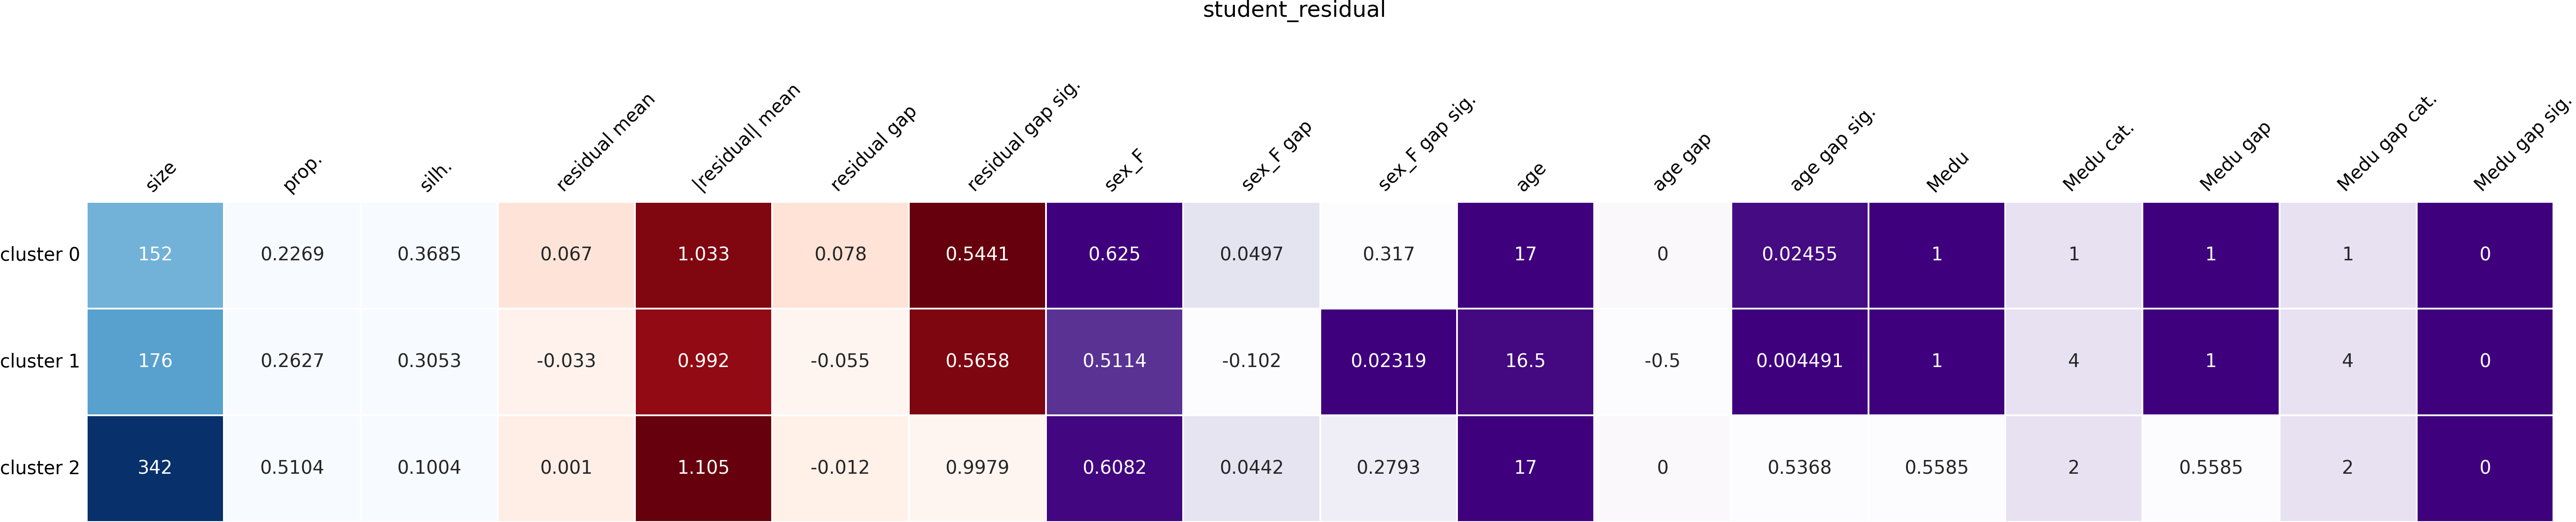

In [7]:
plot_cluster_recap_heatmap(recap.copy(), "student_residual", ".", error_label="residual")
Image("student_residual.png")

## 7. Gower distance on mixed data

The Euclidean baseline in section 3 assumes that after one-hot encoding, straight-line distance in that space is meaningful. For mixed data it usually is not. Numeric columns like `G1` span 0-20 while each one-hot column is 0 or 1, so squared differences add up in favour of the numerics and the categorical axes barely register. Standardising flips the problem: `StandardScaler` divides each column by its standard deviation, and a dummy that is 1 for a handful of students has a tiny one, so scaling inflates it into a high-variance axis. Either way the geometry follows the encoding rather than anything real about the students. Keeping the dummies out of the scaler, as section 3 does, is a partial fix.

Gower distance compares each feature on its own terms and averages. Categorical features contribute a matching dissimilarity, 0 if the two students share the category and 1 if not. Numeric features contribute their difference normalised by the feature's range, so every column lands on a comparable 0-1 scale. No one-hot expansion and no standardisation, and every feature gets an equal vote.

Below we cluster with HDBSCAN on the Gower matrix. HDBSCAN takes a precomputed distance matrix, finds the number of clusters itself, and labels points it cannot assign as `-1`. `min_datapoints` drops clusters too small to trust. The student columns are already numeric codes, so we just tell Gower which indices to treat as categorical.

kmedoids also takes Gower with a fixed k, but it needs `scikit-learn-extra`, which has no wheels for numpy 2.

In [8]:
g_regular = ["G1", "G2", "studytime", "absences"]
g_sensitive = ["sex_F", "Medu", "age"]
g_cols = g_regular + g_sensitive
g_categorical = ["sex_F", "Medu"]                 # matching dissimilarity, not numbers
cat_idx = [g_cols.index(c) for c in g_categorical]

res_g = cluster(df[g_cols], algorithm="hdbscan", distance="gower",
                categorical_features=cat_idx, min_samples=15, min_datapoints=25)
print(f"k = {res_g.n_clusters}   silhouette = {res_g.silhouette:.3f}   noise = {res_g.n_noise}")
print("cluster sizes:", res_g.cluster_sizes)

k = 8   silhouette = 0.493   noise = 37
cluster sizes: {np.int64(0): np.int64(87), np.int64(1): np.int64(57), np.int64(2): np.int64(95), np.int64(3): np.int64(81), np.int64(4): np.int64(121), np.int64(5): np.int64(72), np.int64(6): np.int64(63), np.int64(7): np.int64(57), np.int64(-1): np.int64(37)}


/Users/filip/RA/Clustering_4_Fairness/venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [9]:
# Median residual per Gower cluster and who it holds (-1 is HDBSCAN noise).
gdf = df.assign(residual=residual.values, clusters=res_g.labels)
gower_summary = (
    gdf[gdf["clusters"] != -1]
       .groupby("clusters")
       .agg(n=("residual", "size"),
            median_residual=("residual", "median"),
            median_age=("age", "median"),
            dominant_Medu=("Medu", lambda s: int(s.mode().iloc[0])),
            pct_female=("sex_F", "mean"))
       .assign(abs_residual=lambda d: d["median_residual"].abs())
       .sort_values("abs_residual", ascending=False)
)
gower_summary.round(3)

,n,median_residual,median_age,dominant_Medu,pct_female,abs_residual
clusters,,,,,,
2,95,0.356,17.0,1,1.0,0.356
0,87,0.345,17.0,4,1.0,0.345
4,121,0.174,17.0,2,1.0,0.174
7,57,0.141,17.0,3,0.0,0.141
5,72,0.118,17.0,3,1.0,0.118
1,57,0.053,17.0,1,0.0,0.053
6,63,0.040,17.0,2,0.0,0.040
3,81,-0.026,16.0,4,0.0,0.026


The top row is the Gower partition's most biased cluster, where the model's grades are most systematically off, and `dominant_Medu`, `median_age` and `pct_female` say for whom. Line its composition up against the Euclidean recap from section 5. If the two distances concentrate the error in different subgroups, the result is sensitive to the distance choice.

## 8. Choosing k

Fixing k is a guess. Instead, search a range and let a score pick. `cluster` sweeps `[n_min, n_max]`, scores each k and keeps the best, using the silhouette by default. The silhouette rates a clustering from -1 to 1 by asking, for each point, whether it sits closer to its own cluster than to the nearest other one.

The k search runs in the kmeans family, so we go back to the Euclidean feature matrix from section 3. The CLI spells it `--n_min 2 --n_max 8 --scoring silhouette`. If the top few k score almost the same, the structure is ambiguous, which is itself worth knowing.

In [10]:
res_k = cluster(dfe[clustering_cols], algorithm="kmeans", distance="euclidean",
                n_min=2, n_max=8, random_state=42)
print(f"selected k = {res_k.n_clusters}   silhouette = {res_k.silhouette:.3f}   sizes = {res_k.cluster_sizes}")

  k range: [2, 8]


  Best k=5 (score=0.3042)
  Best k=5 (score=0.304)
selected k = 5   silhouette = 0.304   sizes = {np.int32(0): np.int64(145), np.int32(1): np.int64(191), np.int32(2): np.int64(176), np.int32(3): np.int64(152), np.int32(4): np.int64(6)}


## Takeaway

The audit turns "the model has RMSE X" into "the model is biased by +Y grade points for this subgroup, and the gap is significant", a disparity localised to a pocket of the feature space that a per-attribute average cannot see.

The sign of `error_mean` already separates over- from under-prediction, the regression counterpart of the false-positive / false-negative split in a classification audit. Confusion-matrix subsets like `--subset FP_FN` are classification-only.

Use `distance="gower"` when features are mixed numeric/categorical, and `"euclidean"` after one-hot when everything is genuinely numeric. Use `kmeans` when you want a fixed k or a k search, and `hdbscan` (with `min_samples`, `min_datapoints`) to let the data decide how many clusters exist and drop ones too small to trust.

Auditing one configuration answers whether there is a disparate subgroup. Auditing many answers whether the same subgroup is disparate no matter how you cluster. `--experiment` mode runs each feature-group combination and writes an Overview table plus comparison heatmaps:

```bash
python -m c4fairness.main \
  --data_path docs/datasets/student_grades.csv \
  --algorithm hdbscan --distance gower --min_samples 15 --min_datapoints 25 \
  --regular_cols "G1,G2,studytime,absences" \
  --sensitive_cols "sex_F,Medu,age" --continuous_sensitive_cols "age" \
  --categorical_cols "Medu,sex_F" \
  --error_type regression --y_true_col y_true --y_pred_col y_pred \
  --experiment --no_standardize --projection pca
```